In [ ]:
using OrdinaryDiffEq, CairoMakie, Lux, ConcreteStructs
using ProgressTables, StableRNGs, Optimisers, Printf
using NeuralPDE, Random, OptimizationOptimJL, LineSearches

rng = StableRNG(1234);

[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0](cache misses: wrong dep version loaded (6), incompatible header (1))
┌ Warning: attempting to remove probably stale pidfile
│   path = "C:\\Users\\20169366\\.julia\\compiled\\v1.12\\CairoMakie\\9mSey_SuLb4.ji.pidfile"
└ @ FileWatching.Pidfile C:\Users\20169366\.julia\juliaup\julia-1.12.6+0.x64.w64.mingw32\share\julia\stdlib\v1.12\FileWatching\src\pidfile.jl:250

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling CairoMakie [13f3f980-e62b-5c42-98c6-ff1f3baf88f0] (cache misses: wrong dep version loaded (12), incompatible header (2))


# Physics-informed neural networks
Another variant of hybrid models are physics-informed neural networks (PINNs). In a PINN, neural networks are used to learn both the physical parameters of a system, as well as the solution to the system itself. 

A common example for PINNs, is the damped harmonic oscillator system: 

$$ \frac{\mathrm{d}^2 x}{\mathrm{d}t^2} = -\frac{\mu}{m}\frac{\mathrm{d}
x}{\mathrm{d}t} - \frac{k}{m}x $$

Setting $\frac{\mathrm{d}x}{\mathrm{d}t} = v$, we can implement the system of ODEs:


In [ ]:
function damped_harmonic_oscillator!(du, u, p, t)
    x, v = u
    μ, m, k = p

    du[1] = v
    du[2] = - (μ / m) * v - (k / m) * x
end

damped_harmonic_oscillator! (generic function with 1 method)

Let's simulate some data

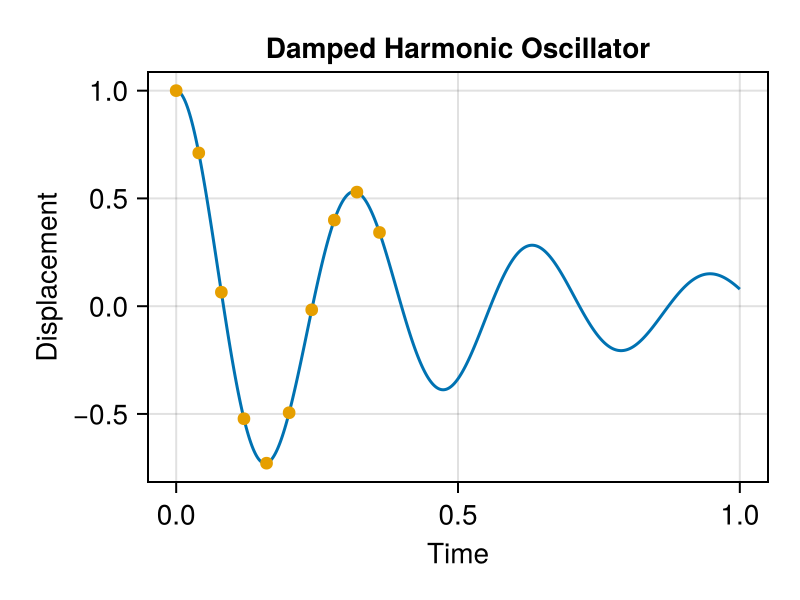

In [ ]:
parameters = [2.0, 0.5, 20*20*0.5]  # μ, m, k

# Make sure we are in the underdamped regime (μ/(2m) < sqrt(k/m))
@assert parameters[1]/(2 * parameters[2]) < sqrt(parameters[3]/parameters[2]) "The system is overdamped. Please choose different parameters."
initial_conditions = [1.0, 0.0]  # x₀, v₀

tspan = (0.0, 1.0)

prob = ODEProblem(damped_harmonic_oscillator!, initial_conditions, tspan, parameters)
sol = solve(prob, Tsit5(), saveat=range(0,1,500))


x_data = sol.t[1:20:200]
y_data = sol[1, 1:20:200]

figure_dho = let f = Figure(size=(400,300))
    ax = Axis(f[1, 1], xlabel = "Time", ylabel = "Displacement", title = "Damped Harmonic Oscillator")
    lines!(ax, sol.t, sol[1, :], color = Makie.wong_colors()[1])
    scatter!(ax, x_data, y_data, color = Makie.wong_colors()[2])
    f
end

In [ ]:
train_data = (Float32.(x_data'), Float32.(y_data'))
val_data = (Float32.(sol.t[200:20:end]'), Float32.(sol[1, 200:20:end]'))

(Float32[0.3987976 0.43887776 … 0.9599198 1.0], Float32[0.008141761 -0.2937188 … 0.14562382 0.078993894])

## Regular neural network

Set up the training loop

In [ ]:
function fit(model, train_data, val_data; epochs=1000, lr=1e-3, rng=StableRNG(1234))

    loss_function = MSELoss()

    ps, st = Lux.setup(rng, model)

    opt = Adam(lr)

    tstate = Training.TrainState(model, ps, st, opt)

    vjp_rule = AutoZygote()

    pt = IncrementalProgressTable(;
        header=["Epoch", "Train Loss", "Validation Loss"],
        widths=[10, 24, 24],
        format=["%3d", "%.6f", "%.6f"],
        color=[:normal, :normal, :normal],
        border=true,
        alignment=[:center, :center, :center],
    )
    println("Training the model...")
    for epoch in 1:epochs
        _, loss, _, tstate = Training.single_train_step!(vjp_rule, loss_function, train_data, tstate)
        pred_val = Lux.apply(tstate.model, val_data[1], tstate.parameters, Lux.testmode(tstate.states)) |> first |> cdev
        val_loss = loss_function(pred_val, val_data[2])

        if epoch % 50 == 0 || epoch == 1
                    next(
            pt, [
                epoch, loss, val_loss
            ]
        )
        end

    end
    return tstate
end



fit (generic function with 1 method)

In [ ]:
network = FullyConnectedNetwork(1, 1, 32, 3)
result = fit(network, train_data, val_data; epochs=1000, lr=1e-3)

[ Info: Compiling the forward pass...


Training the model...


[ Info: Forward pass compiled.


│      1   │        0.904822        │        0.365991        │
│     50   │        0.280930        │        0.054450        │
│    100   │        0.230426        │        0.205413        │
│    150   │        0.173117        │        0.434353        │
│    200   │        0.113820        │        0.674603        │
│    250   │        0.066757        │        0.752529        │
│    300   │        0.039456        │        0.682138        │
│    350   │        0.026559        │        0.551505        │
│    400   │        0.020312        │        0.446829        │
│    450   │        0.016461        │        0.376768        │
│    500   │        0.013575        │        0.321058        │
│    550   │        0.011253        │        0.270114        │
│    600   │        0.009336        │        0.222735        │
│    650   │        0.007736        │        0.180335        │
│    700   │        0.006392        │        0.145562        │
│    750   │        0.005286        │        0.123352  

TrainState(
    FullyConnectedNetwork(
        model = Chain(
            layer_1 = Dense(1 => 32, tanh),       # 64 parameters
            layer_2 = Dense(32 => 32, tanh),      # 1_056 parameters
            layer_3 = Dense(32 => 1),             # 33 parameters
        ),
    ),
    number of parameters: 1153
    number of states: 0
    optimizer: ReactantOptimiser(Adam(eta=ConcretePJRTNumber{Float64, 1}(0.001), beta=(ConcretePJRTNumber{Float64, 1}(0.9), ConcretePJRTNumber{Float64, 1}(0.999)), epsilon=ConcretePJRTNumber{Float64, 1}(1.0e-8)))
    step: 1000
    cache: TrainingBackendCache(Lux.Training.ReactantBackend{Static.True, Missing, Nothing, AutoEnzyme{Nothing, Nothing}}(static(true), missing, nothing, AutoEnzyme()))
    objective_function: GenericLossFunction
)


In [ ]:
params = result.parameters |> cpu_device()

(layer_1 = (weight = Float32[1.178932; -2.6824608; … ; -2.727854; -2.2119677;;], bias = Float32[0.10821972, 0.49390694, 0.3164503, -0.55027956, -0.74685484, 0.103598684, -0.44404322, 0.75269437, 0.13924849, -0.4492224  …  -0.07759785, -0.3345461, 0.061560392, 0.44370082, -0.7478719, -0.54058444, -0.5796115, 0.30156586, 0.43474203, 0.15025118]), layer_2 = (weight = Float32[0.4449158 -0.24228248 … 0.36099774 0.46475437; -0.22042859 0.13750358 … 0.8477552 0.46541923; … ; -0.3577367 0.13186964 … 0.4017809 0.11875118; 0.4708656 0.24003851 … 0.45223954 -0.10352618], bias = Float32[0.07805593, -0.02917605, -0.112155825, -0.09679149, -0.10024626, -0.013397936, 0.14623831, -0.13712294, 0.20691107, -0.10958308  …  -0.114078656, -0.20796794, 0.029434154, -0.018715821, 0.24806252, -0.14610349, -0.022798011, -0.021942217, -0.16026936, -0.061891988]), layer_3 = (weight = Float32[0.14443715 -0.28383398 … -0.2896633 0.07184905], bias = Float32[0.07604334]))

Let's inspect our NN solution

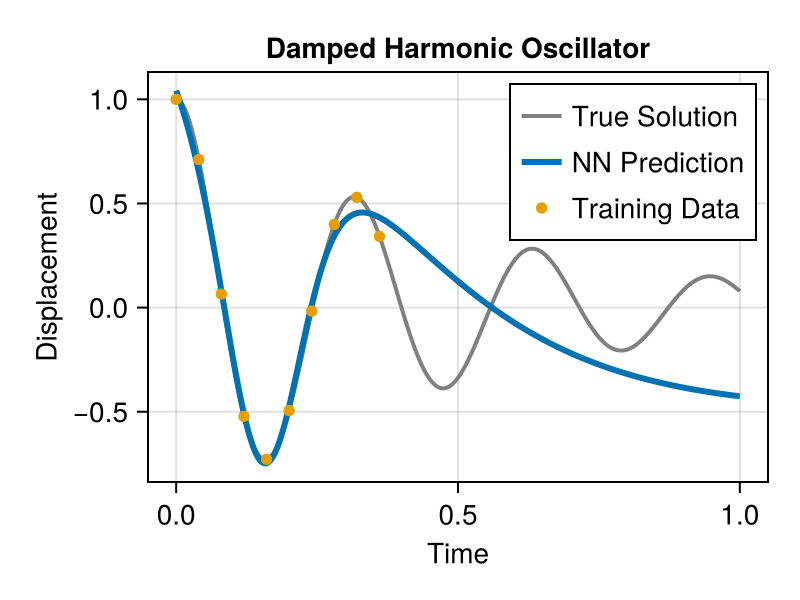

In [ ]:
figure_nn_prediction = let f = Figure(size=(400,300))
    ax = Axis(f[1, 1], xlabel = "Time", ylabel = "Displacement", title = "Damped Harmonic Oscillator")
    lines!(ax, sol.t, sol[1, :], color = :gray, label= "True Solution", linewidth=2)

    test_x = Float32.(sol.t')
    test_y = result.model(test_x, params, Lux.testmode(result.states))[1]
    lines!(ax, test_x[1,:], test_y[:], color = Makie.wong_colors()[1], label = "NN Prediction", linewidth=3)

    scatter!(ax, x_data, y_data, color = Makie.wong_colors()[2], label = "Training Data", markersize=8)
    axislegend(ax)
    f
end

## Training a PINN with neuralPDE

In [ ]:
rng = Random.default_rng()
Random.seed!(rng, 0)

chain = Chain(Dense(1, 32, tanh), Dense(32, 32, tanh), Dense(32, 1))
ps, st = Lux.setup(rng, chain) |> f64

In [ ]:
additional_loss(phi, θ) = sum(abs2, phi(x_data, θ) - y_data) / length(y_data)

In [ ]:
opt = LBFGS(linesearch = BackTracking())
alg = NNODE(chain, opt, ps; strategy = WeightedIntervalTraining([0.7, 0.2, 0.1], 500),
    param_estim = true, additional_loss)

In [ ]:
p_init = [1.0, 1.0, 1.0]  # Initial guess for μ, m, k
prob = ODEProblem(damped_harmonic_oscillator!, initial_conditions, tspan, p_init)
sol_pinn = solve(prob, alg, verbose = true, abstol = 1e-8, maxiters = 10000, saveat = 0.1)

In [ ]:
figure_pinn_prediction = let f = Figure(size=(400,300))
    ax = Axis(f[1, 1], xlabel = "Time", ylabel = "Displacement", title = "Damped Harmonic Oscillator")
    lines!(ax, sol.t, sol[1, :], color = :gray, label= "True Solution", linewidth=2)

    test_x = Float32.(sol.t')
    test_y = result.model(test_x, params, Lux.testmode(result.states))[1]
    lines!(ax, test_x[1,:], test_y[:], color = Makie.wong_colors()[1], label = "NN Prediction", linewidth=3)

    lines!(ax, sol_pinn.t, sol_pinn[1, :], color = Makie.wong_colors()[3], label = "PINN Prediction", linewidth=3)

    scatter!(ax, x_data, y_data, color = Makie.wong_colors()[2], label = "Training Data", markersize=8)
    axislegend(ax)
    f
end

In [ ]:
sol.k.u.p